In [ ]:
#The following code was used to sanitize the data and store it in proper list.

In [251]:
import torch
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("companies.csv")

In [14]:
df.shape

(11420, 16383)

In [99]:
data = df.iloc[:,0]

In [119]:
names = (set(data.tolist()))

In [229]:
with open("sanitized_companies.txt", "w") as f:
    for name in names:
        if pd.notna(name) and name.isascii():
            sanName = re.sub(r'\(.*?\)|\[.*?\]|\{.*?\}|-.*|:.*|–.*|\|.*|[,，!$%&+\s\'’",./_@]', '', name)
            f.write(str(sanName) + "\n");

In [166]:
#default loading of the sanitized companies list:

In [230]:
data = [item.lower() for item in open("sanitized_companies.txt", "r").read().split('\n')]

In [914]:
engWords = open("better_words.txt", "r").read().split('\n')

In [256]:
chars = sorted((set(''.join(data))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [905]:
len(engWords), len(data)

(3000, 9096)

In [998]:
rawCounts = torch.zeros((37,37), dtype=torch.int32)

In [990]:
for name in data:
    aug = '.' + str(name).lower() + '.' #augmenting . to hallucinate the start and the end token
    for ch1, ch2 in zip(aug[0:], aug[1:]):
        rawCounts[stoi[ch1], stoi[ch2]] += 1

In [ ]:
for word in engWords:
    aug = '.' + word.lower() + '.'
    for ch1, ch2 in zip(aug[0:], aug[1:]):
        rawCounts[stoi[ch1], stoi[ch2]] += 3 #3x weightage for generating english names

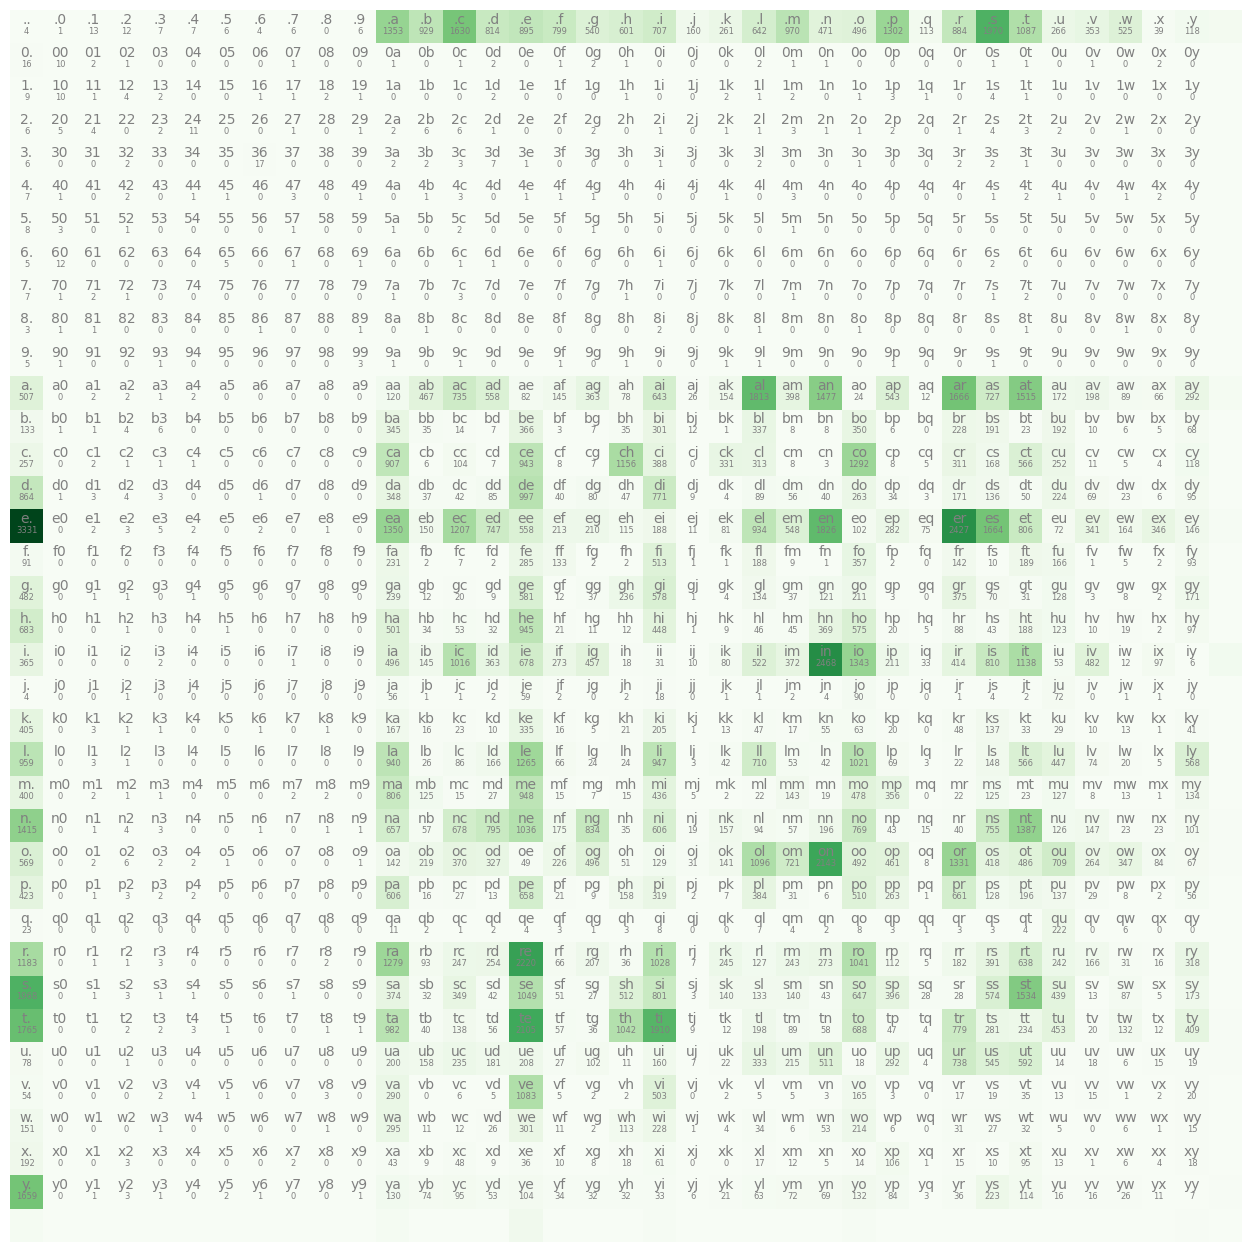

In [932]:
%matplotlib inline

plt.figure(figsize=(16,16))
plt.axis('off')
plt.imshow(rawCounts, cmap = 'Greens')
for i in range(36):
    for j in range(36):
        label = itos[i] + itos[j]
        plt.text(j, i, label, ha = "center", va = "bottom", color = 'grey')
        plt.text(j, i, rawCounts[i,j].item(), ha = "center", va = "top", color = 'grey', size = '6')

In [995]:
rowSum = rawCounts.sum(dim=1, keepdim = True)
probTable = rawCounts/rowSum

In [1022]:
generations = []
for i in range(10):
    currTokId = stoi['.']
    currString = ''
    while True:
        nextTokId = torch.multinomial(probTable[currTokId], num_samples=1,replacement=True, generator = generator).item()
        nextTok = itos[nextTokId]
        if nextTok == '.': break;
        currString+= nextTok
        currTokId = nextTokId
    generations.append(currString)
generations

['me', 't', 'de', 'cas', 'h', 'ghow', 'w', 'fe', 'datath', 'diniotrtegencrmen']